# 01 - Vehicle Overview

The **Archer Midnight** is a battery-electric eVTOL aircraft designed for urban air mobility. This notebook loads an Archer Midnight configuration and inspects its key parameters.

The Midnight uses a **tilt rotor with dedicated lift rotor** architecture: dedicated lift rotors for hover and tilt rotors that transition to forward thrust. This is one of several eVTOL architectures (others include tilt-wing and multicopter), each with different trade-offs between hover efficiency, cruise efficiency, and complexity.

## Archer Midnight at a Glance

| Parameter | Value | Design Significance |
|-----------|-------|---------------------|
| MTOW | 3,175 kg (7,000 lb) | Sets structural and power requirements |
| Payload | 454 kg (1,000 lb) | Fixed by mission requirement (pilot + passengers) |
| Wingspan | 15.24 m (50 ft) | Determines wing area, aspect ratio, and cruise L/D |
| Rotor Count | 12 (6 lift + 6 tilt) | Provides hover redundancy and OEI capability |
| Rotor Diameter | 2.0 m | Sets disk loading and hover power |
| Cruise Speed | 67.1 m/s (130 kts) |  |
| Battery Specific Energy | 256 Wh/kg | Cell-level; derated at pack level |

## Setup

We load the Archer Midnight configuration from the tutorial JSON file.

In [1]:
import sys
sys.path.append('../../evtol')
from aircraft import Aircraft

ac = Aircraft('../Archer_Midnight.json')

## Geometry and Configuration

Key geometry relationships:
- **Wing area** is sized by the stall speed requirement: $S = \frac{2mg}{\rho V_{stall}^2 C_{L,max}}$
- **Aspect ratio** ($AR = b^2/S$) determines induced drag, higher AR = lower induced drag but longer, heavier spars
- **Taper ratio** affects spanwise lift distribution and structural efficiency

In [2]:
print("=== Geometry ===")
print(f"  Wingspan:          {ac.wingspan_m:.2f} m")
print(f"  Wing Area:         {ac.wing_area_m2:.2f} m^2")
print(f"  Wing Aspect Ratio: {ac.wing_aspect_ratio:.2f}")
print(f"  Wing Taper Ratio:  {ac.wing_taper_ratio:.2f}")
print(f"  Wing t/c:          {ac.wing_t_p_c:.2f}")
print()
print("=== Fuselage ===")
print(f"  Length: {ac.fuselage_l_m:.2f} m")
print(f"  Width:  {ac.fuselage_w_m:.2f} m")
print(f"  Height: {ac.fuselage_h_m:.2f} m")
print()
print("=== Propulsion ===")
print(f"  Rotor Count:       {ac.propulsion.rotor_count}")
print(f"  Lift Rotors:       {ac.propulsion.lift_rotor_count}")
print(f"  Tilt Rotors:       {ac.propulsion.tilt_rotor_count}")
print(f"  Rotor Diameter:    {ac.propulsion.rotor_diameter_m:.2f} m")
print(f"  Disk Area (total): {ac.propulsion.disk_area_m2:.2f} m^2")

=== Geometry ===
  Wingspan:          15.24 m
  Wing Area:         21.19 m^2
  Wing Aspect Ratio: 10.96
  Wing Taper Ratio:  0.40
  Wing t/c:          0.15

=== Fuselage ===
  Length: 9.00 m
  Width:  1.60 m
  Height: 1.60 m

=== Propulsion ===
  Rotor Count:       12
  Lift Rotors:       6
  Tilt Rotors:       6
  Rotor Diameter:    2.00 m
  Disk Area (total): 37.70 m^2


## Aerodynamic Properties

The cruise aerodynamic properties are computed from the geometry using a component drag buildup method (see [06 - Aerodynamics](../06%20-%20Aerodynamics/)).

The cruise L/D is the single most important metric for cruise energy: $P_{cruise} = \frac{mgV}{\eta_{rotor} \cdot (L/D)}$

In [3]:
print("=== Cruise Aerodynamics ===")
print(f"  Stall Speed:  {ac.stall_speed_m_p_s:.1f} m/s")
print(f"  Cruise Speed: {ac.mission.cruise_h_m_p_s:.1f} m/s")
print(f"  Cruise CL:    {ac.cruise_cl:.4f}")
print(f"  Cruise CD:    {ac.cruise_cd:.6f}")
print(f"  Cruise L/D:   {ac.cruise_l_p_d:.2f}")

=== Cruise Aerodynamics ===
  Stall Speed:  40.0 m/s
  Cruise Speed: 66.9 m/s
  Cruise CL:    0.5355
  Cruise CD:    0.050257
  Cruise L/D:   10.66


## Battery and Power Parameters

The battery and electric propulsion unit (EPU) parameters define the energy storage and conversion chain:

$$\text{Cell spec energy} \xrightarrow{K_{int}} \xrightarrow{(1-f_{inacc})} \xrightarrow{f_{EOL}} \text{Pack usable energy}$$

The EPU efficiency ($\eta_{epu}$) converts shaft power to electric power: $P_{elec} = P_{shaft} / \eta_{epu}$

In [4]:
print("=== Battery ===")
print(f"  Specific Energy:     {ac.power.batt_spec_energy_w_h_p_kg:.0f} Wh/kg")
print(f"  Integration Factor:  {ac.power.batt_int_factor:.2f}")
print(f"  Inaccessible Frac:   {ac.power.batt_inaccessible_energy_frac:.2f}")
print(f"  End-of-Life Cap:     {ac.power.batt_eol_capacity:.2f}")
print()
usable_spec = (ac.power.batt_spec_energy_w_h_p_kg
               * ac.power.batt_int_factor
               * (1 - ac.power.batt_inaccessible_energy_frac)
               * ac.power.batt_eol_capacity)
print(f"  Usable Specific Energy: {usable_spec:.1f} Wh/kg")
print(f"    = {ac.power.batt_spec_energy_w_h_p_kg} x {ac.power.batt_int_factor} x (1 - {ac.power.batt_inaccessible_energy_frac}) x {ac.power.batt_eol_capacity}")
print()
print("=== EPU ===")
print(f"  EPU Efficiency:      {ac.power.epu_effic:.2f}")
print(f"  Hover Power Effic:   {ac.power.hover_power_effic:.2f}")

=== Battery ===
  Specific Energy:     256 Wh/kg
  Integration Factor:  0.80
  Inaccessible Frac:   0.05
  End-of-Life Cap:     0.80

  Usable Specific Energy: 155.6 Wh/kg
    = 256.0 x 0.8 x (1 - 0.05) x 0.8

=== EPU ===
  EPU Efficiency:      0.92
  Hover Power Effic:   0.74


## Hover Performance

Hover power is derived from momentum theory. The induced velocity in hover is:

$$v_i = \sqrt{\frac{T}{2\rho A}} \qquad P_{hover} = T \cdot v_i$$

**Disk loading** ($DL = W/A_{disk}$) is the key parameter: lower disk loading means less induced velocity and less power, but requires larger rotors.

=== Hover ===
  MTOW:             3175 kg
  Disk Area:        37.70 m^2
  Disk Loading:     826.2 N/m^2
  Hover Shaft Power:    772.93 kW
  Hover Electric Power: 840.14 kW


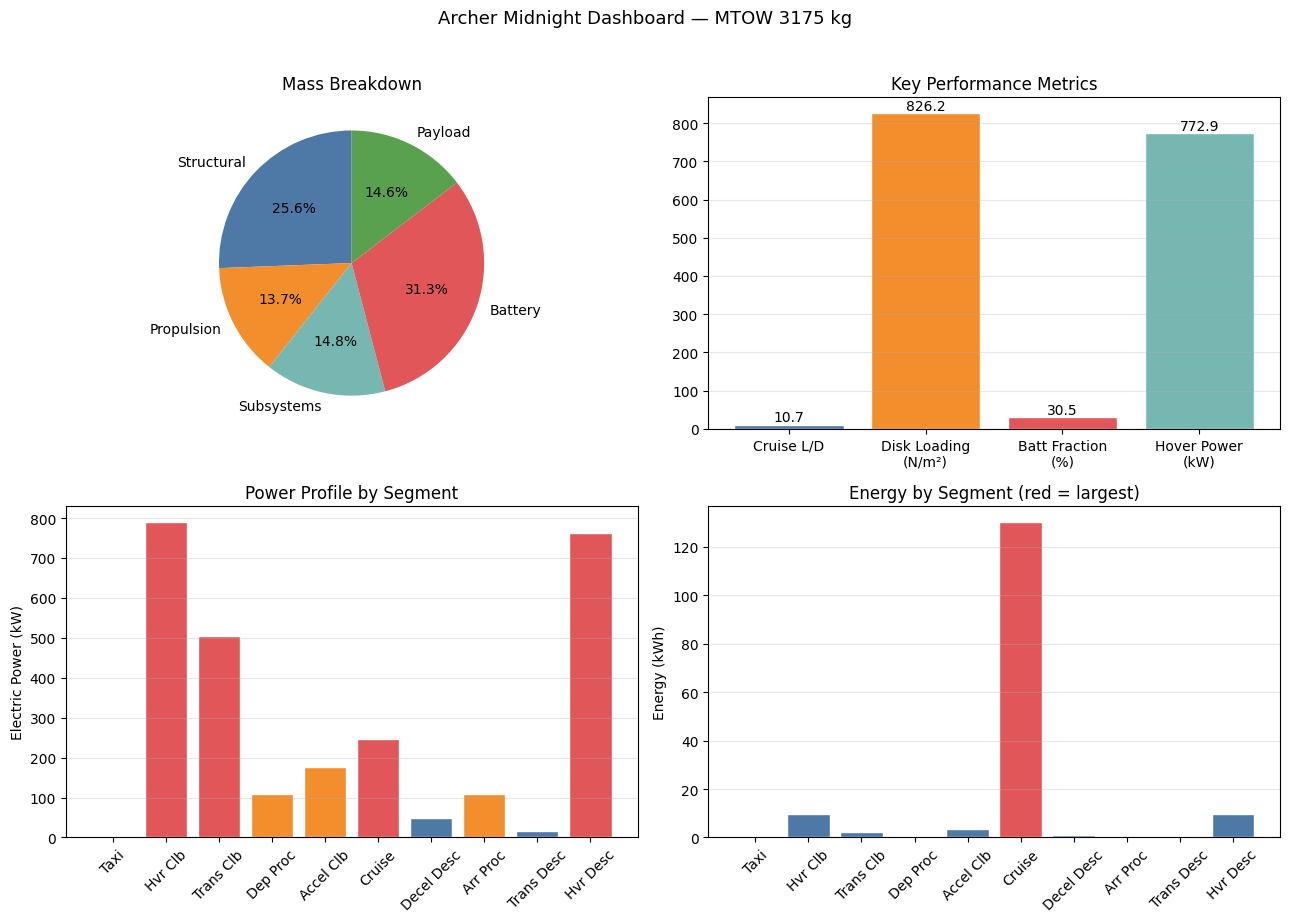

In [ ]:
import matplotlib.pyplot as plt

disk_loading = (ac.max_takeoff_mass_kg * ac.environ.g_m_p_s2) / ac.propulsion.disk_area_m2

print("=== Hover ===")
print(f"  MTOW:             {ac.max_takeoff_mass_kg:.0f} kg")
print(f"  Disk Area:        {ac.propulsion.disk_area_m2:.2f} m^2")
print(f"  Disk Loading:     {disk_loading:.1f} N/m^2")
print(f"  Hover Shaft Power:    {ac.hover_shaft_power_kw:.2f} kW")
print(f"  Hover Electric Power: {ac.hover_shaft_power_kw / ac.power.epu_effic:.2f} kW")

# Summary dashboard
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Mass breakdown pie
structural = ac.wing_mass_kg + ac.horiz_tail_mass_kg + ac.vert_tail_mass_kg + ac.fuselage_mass_kg + ac.boom_mass_kg + ac.landing_gear_mass_kg
propulsion = ac.epu_mass_kg + ac.lift_rotor_hub_mass_kg + ac.tilt_rotor_mass_kg
subsystems = ac.actuator_mass_kg + ac.furnishings_mass_kg + ac.environmental_control_system_mass_kg + ac.avionics_mass_kg + ac.hivolt_power_dist_mass_kg + ac.lovolt_power_coms_mass_kg
groups = ['Structural', 'Propulsion', 'Subsystems', 'Battery', 'Payload']
masses = [structural, propulsion, subsystems, ac.battery_mass_kg, ac.payload_kg]
colors = ['#4e79a7', '#f28e2b', '#76b7b2', '#e15759', '#59a14f']
axes[0,0].pie(masses, labels=groups, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0,0].set_title('Mass Breakdown')

# 2. Key performance metrics
metrics = ['Cruise L/D', 'Disk Loading\n(N/m²)', 'Batt Fraction\n(%)', 'Hover Power\n(kW)']
values = [ac.cruise_l_p_d, disk_loading, 100*ac.battery_mass_kg/ac.max_takeoff_mass_kg, ac.hover_shaft_power_kw]
bar_colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
bars = axes[0,1].bar(metrics, values, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{val:.1f}', ha='center', va='bottom', fontsize=10)
axes[0,1].set_title('Key Performance Metrics')
axes[0,1].grid(True, alpha=0.3, axis='y')

# 3. Power profile
segs = [
    ('Taxi', ac.depart_taxi_avg_electric_power_kw),
    ('Hvr Clb', ac.hover_climb_avg_electric_power_kw),
    ('Trans Clb', ac.trans_climb_avg_electric_power_kw),
    ('Dep Proc', ac.depart_proc_avg_electric_power_kw),
    ('Accel Clb', ac.accel_climb_avg_electric_power_kw),
    ('Cruise', ac.cruise_avg_electric_power_kw),
    ('Decel Desc', ac.decel_descend_avg_electric_power_kw),
    ('Arr Proc', ac.arrive_proc_avg_electric_power_kw),
    ('Trans Desc', ac.trans_descend_avg_electric_power_kw),
    ('Hvr Desc', ac.hover_descend_avg_electric_power_kw),
    ('Taxi', ac.arrive_taxi_avg_electric_power_kw),
]
seg_names_p = [s[0] for s in segs]
seg_powers = [s[1] for s in segs]
pcolors = ['#e15759' if p > 200 else '#f28e2b' if p > 100 else '#4e79a7' for p in seg_powers]
axes[1,0].bar(seg_names_p, seg_powers, color=pcolors, edgecolor='white')
axes[1,0].set_ylabel('Electric Power (kW)')
axes[1,0].set_title('Power Profile by Segment')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3, axis='y')

# 4. Energy by segment
seg_energies = [
    ac.depart_taxi_energy_kw_hr, ac.hover_climb_energy_kw_hr,
    ac.trans_climb_energy_kw_hr, ac.depart_proc_energy_kw_hr,
    ac.accel_climb_energy_kw_hr, ac.cruise_energy_kw_hr,
    ac.decel_descend_energy_kw_hr, ac.arrive_proc_energy_kw_hr,
    ac.trans_descend_energy_kw_hr, ac.hover_descend_energy_kw_hr,
    ac.arrive_taxi_energy_kw_hr,
]
ecolors = ['#e15759' if e == max(seg_energies) else '#4e79a7' for e in seg_energies]
axes[1,1].bar(seg_names_p, seg_energies, color=ecolors, edgecolor='white')
axes[1,1].set_ylabel('Energy (kWh)')
axes[1,1].set_title('Energy by Segment')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Archer Midnight Overview MTOW {ac.max_takeoff_mass_kg:.0f} kg', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Summary

The Archer Midnight is a tilt rotor + dedicated lift rotor eVTOL with:

- A **15.24 m wingspan** producing a high cruise L/D, this is the primary driver of cruise efficiency
- **12 rotors** (6 lift + 6 tilt) providing redundant hover capability and OEI margins
- A **243 Wh/kg** battery pack at the cell level, significantly derated at the pack level
- **Hover power** driven by disk loading via momentum theory ($P \propto T^{3/2}/\sqrt{\rho A}$)
- **Cruise power** driven by L/D via drag buildup ($P = mgV/(\eta \cdot L/D)$)
- **Battery mass** as the largest single mass component, creating the circular dependency that requires iterative sizing

**Next:** [02 - Sizing and MTOW Convergence]